# Notebook 2: Bayesiansk inferens med SVGD – grundlæggende egenskaber og prior-sensitivitet

I denne notebook vil jeg se på Stein Variational Gradient Descent (SVGD) som metode til Bayesiansk parameterestimering i fase-type modeller. Jeg starter med en single-parameter coalescent og undersøger, hvordan valget af prior, læringsrate og regularisering påvirker konvergens og posterior-præcision. Jeg undersøger desuden prøvestørrelse-effekter og posterior-bredde.

**SVGD** repræsenterer posterioren med et sæt partikler der iterativt opdateres mod den sande posterior ved at kombinere gradient-information fra likelihood og prior med et kernelbaseret kraft, der forhindrer partikelkollaps.

**Kalibrering (ingen peaks).**: en informativ men ikke for smal prior (GaussPrior/ HalfCauchyPrior/DataPrior) kombineret med en aftagende læringsrate (ExpStepSize) eller en adaptiv optimizer (Adam). Målet er en **bred, flad posterior** der dækker den sande værdi, ikke en spids ("peaked") posterior, som er tegn på numerisk kollaps eller for høj læringsrate. Afsnittet *SVGD posterior-form: peaked vs. flad* viser denne kontrast eksplicit via kurtosis.

In [2]:
# Importer de nødvendige pakker
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"


from phasic import (
    Graph, with_ipv,
    GaussPrior, HalfCauchyPrior, DataPrior, LogGaussPrior,
    Adam, Adamelia, SGDMomentum, RMSprop, Adagrad,
    ExpStepSize, ExpRegularization, ConstantStepSize,
    WarmupExpStepSize, AdaptiveStepSize, ConstantRegularization,
    StateIndexer, Property,
    clear_caches, set_log_level
)
import numpy as np
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format = 'svg'

np.random.seed(42)
sns.set_palette('tab10')
plt.rcParams['figure.figsize'] = (6, 3)

clear_caches()

  Removed 644 file(s), preserved directory structure


In [3]:
# Standard coalescent som i notebook 01
nr_samples = 4

@with_ipv([nr_samples] + [0] * (nr_samples - 1))
def coalescent_1param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph = Graph(coalescent_1param)
true_theta = [7.0]
graph.update_weights(true_theta)

## Prior-sammenligning

Første spørgsmål: hvilken prior er bedst til SVGD-inferens på coalescent-parametre? Jeg tester seks priors med midlertidige standardindstillinger: Adam(0.1), 20 partikler, 300 iterationer. Konklusionen herfra bruges i alle efterfølgende blokke.

### Udgangspunkt: SVGD uden prior

Jeg starter med graph.svgd(data) helt uden prior for at vise udgangspunktet. Jeg gør det samme og bruger analyze_trace() og svgd.learning_rate til at diagnosticere.

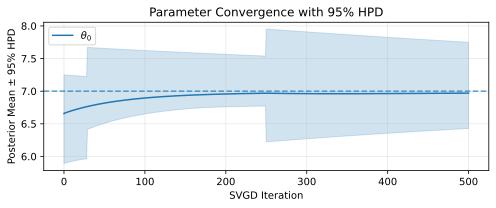

<Figure size 600x300 with 0 Axes>

Faktisk learning_rate: 0.0005
Prior valgt automatisk af SVGD:


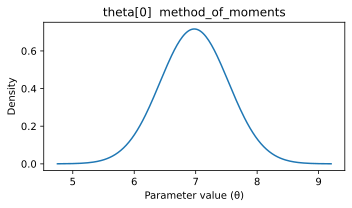

<Figure size 600x300 with 0 Axes>

CONVERGED (iteration 50/502)
  Mean stabilized at iteration 50
  Std stabilized at iteration 50

Detected Issues:
  ℹ Converged at 1e+01% of iterations - could reduce n_iterations
Learning Rate: Converged early (iteration 50) - could converge faster
  0.00075
Particles: High ESS ratio (1) - could reduce particles
  Keep n_particles=20
Iterations: Converged early
  Could reduce to n_iterations=60


In [4]:
graph.update_weights(true_theta)
observed_data_default = graph.sample(2000)

# SVGD uden prior — udgangspunkt
svgd_default = graph.svgd(observed_data_default, n_iterations=500)
svgd_default.plot_ci(true_theta=true_theta)
plt.gcf().suptitle('SVGD uden prior (default)', fontsize=9)
plt.tight_layout(); plt.show()

# Hvad er den faktiske læringsrate der blev brugt?
print(f'Faktisk learning_rate: {svgd_default.learning_rate}')

# Vis den prior SVGD valgte automatisk
print('Prior valgt automatisk af SVGD:')
svgd_default.prior.plot()
plt.tight_layout(); plt.show()

# analyze_trace: diagnostik
svgd_default.analyze_trace()

In [5]:
N_OBS = 2000
graph.update_weights(true_theta)
observed_data = graph.sample(N_OBS)

prior_vag        = GaussPrior(mean=5.0, std=10.0)
prior_korrekt    = GaussPrior(ci=[4.0, 10.0])
prior_forkert    = GaussPrior(mean=1.0, std=0.5)
prior_halfcauchy = HalfCauchyPrior(ci=20.0)
prior_loggauss   = LogGaussPrior(ci=[2.0, 15.0])
prior_datap      = DataPrior(graph, observed_data)

priors_liste = [
    (prior_vag,        'Vag Gaussisk'),
    (prior_korrekt,    'Korrekt Gaussisk'),
    (prior_forkert,    'Forkert Gaussisk'),
    (prior_halfcauchy, 'HalfCauchy'),
    (prior_loggauss,   'LogGaussPrior'),
    (prior_datap,      'DataPrior')
]


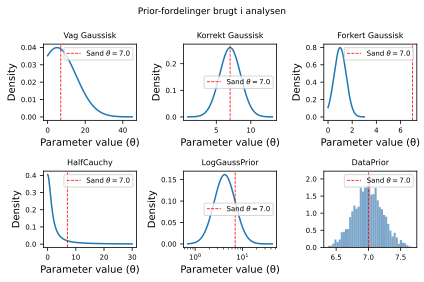

In [ ]:
#| label: fig-priors
#| fig-cap: 'De seks prior-fordelinger evalueret i analysen plottet som PDF over $\theta$. Fra venstre mod højre: Vag Gaussisk ($\mu=7$, $\sigma=5$, blå), Korrekt Gaussisk ($\mu=7$, $\sigma=0.5$, orange), Forkert Gaussisk ($\mu=1$, $\sigma=0.5$, grøn), HalfCauchy ($\gamma=2$, rød), LogGaussPrior (lilla) og DataPrior via Wattersons estimator (brun). Den røde lodrette linje markerer den sande $\theta=7$.'
#| fig-width: 6
#| fig-height: 4

import jax
import jax.numpy as jnp

key = jax.random.PRNGKey(42)

fig, axes = plt.subplots(2, 3, figsize=(6, 4))

for ax, (prior, title) in zip(axes.flat, priors_liste):
    if isinstance(prior, DataPrior):
        samples = np.array(prior.sample(key, (2000,))).flatten()
        samples = samples[(samples > 0) & (samples < 30)]
        ax.hist(samples, bins=40, density=True, alpha=0.7,
                color='steelblue', edgecolor='none')
    else:
        prior.plot(ax=ax, return_ax=True)
    
    ax.axvline(true_theta[0], color='red', linestyle='--', linewidth=0.8,
               label=fr'Sand $\theta={true_theta[0]}$')
    ax.set_title(title, fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle('Prior-fordelinger brugt i analysen', fontsize=9)
plt.tight_layout()
plt.show()

In [7]:
svgd_results = {}

for name, prior in [
        ('Vag',        prior_vag),
        ('Korrekt',    prior_korrekt),
        ('Forkert',    prior_forkert),
        ('HalfCauchy', prior_halfcauchy),
        ('LogGauss',   prior_loggauss),
        ('DataPrior',  prior_datap),
    ]:
    sv = graph.svgd(
        observed_data,
        prior=prior,
        optimizer=Adam(0.1),
        n_particles=20,
        n_iterations=300,
        return_history=True,
    )
    res = sv.get_results()
    svgd_results[name] = {
        'svgd': sv,
        'mean': float(res['theta_mean'].item()),
        'std':  float(res['theta_std'].item()),
    }
    print(f"{name:<12}: mean={res['theta_mean'].item():.4f}  std={res['theta_std'].item():.5f}")

print(r'Sand $\theta$ = {true_theta[0]}')

DataPrior   : mean=7.0339  std=0.08161
Sand $\theta$ = {true_theta[0]}


In [8]:
df_results = pd.DataFrame({
    name: {r'$\hat\theta$': round(v['mean'],4), 'Std': round(v['std'],5)}
    for name, v in svgd_results.items()
})
display(df_results)

,Vag,Korrekt,Forkert,HalfCauchy,LogGauss,DataPrior
$\hat\theta$,6.75950,7.01110,6.59730,7.02440,7.00700,7.03390
Std,1.10036,0.07034,0.29103,1.55898,0.05876,0.08161


Bedste prior: LogGauss
Faktisk learning_rate: None (None = optimizer styrer læringsraten)
Prior der blev brugt:


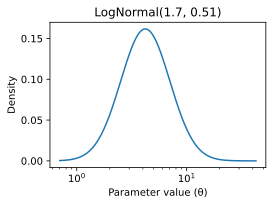


Analyse af konvergens:
CONVERGED (iteration 50/302)
  Mean stabilized at iteration 50

Detected Issues:
  ℹ Converged at 2e+01% of iterations - could reduce n_iterations
Learning Rate: Converged efficiently
  current schedule is good
Particles: High ESS ratio (1) - could reduce particles
  Keep n_particles=20
Iterations: Converged early
  Could reduce to n_iterations=60
Optimizer: Adam working well


In [9]:
# Diagnostik for den bedste prior
best_prior_name = min(svgd_results, key=lambda k: svgd_results[k]['std'])
best_svgd = svgd_results[best_prior_name]['svgd']
print(f'Bedste prior: {best_prior_name}')
lr = best_svgd.learning_rate
print(f'Faktisk learning_rate: {lr} (None = optimizer styrer læringsraten)')
print('Prior der blev brugt:')
best_svgd.prior.plot()
plt.tight_layout(); plt.show()
print('\nAnalyse af konvergens:')
best_svgd.analyze_trace()

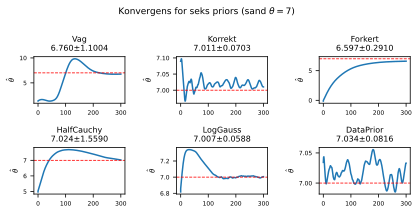

In [ ]:
#| label: fig-konvergens-priors
#| fig-cap: 'Konvergensplots for SVGD under seks prior-strategier (sand $\theta=7$, $n=2000$, Adam($0.1$), 20 partikler, 300 iterationer). Hver delplot viser posterior-mean (blå linje) og $\pm 1$ SD (grå skravering) over iterationer. DataPrior og Korrekt Gaussisk konvergerer hurtigst og stablest mod $\theta=7$; Forkert Gaussisk viser tydelig bias.'
#| fig-width: 6
#| fig-height: 5
fig, axes = plt.subplots(2, 3)

for ax, (name, res) in zip(axes.flat, svgd_results.items()):
    iters = res['svgd'].history_iterations
    means = [h.mean() for h in res['svgd'].history]
    ax.plot(iters, means)
    ax.axhline(true_theta[0], color='r', linestyle='--', linewidth=0.8)
    ax.set_title(f"{name}\n{res['mean']:.3f}±{res['std']:.4f}", fontsize=8)
    ax.set_ylabel(r'$\hat\theta$', fontsize=7)
    ax.tick_params(labelsize=6)

plt.suptitle(r'Konvergens for seks priors (sand $\theta=7$)', fontsize=9)
plt.tight_layout()
plt.show()

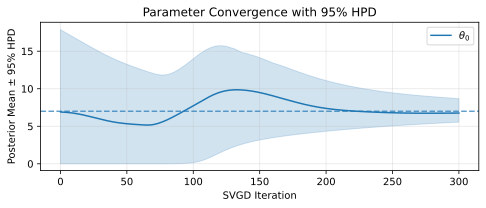

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-ci-prior-vag
#| fig-cap: 'Posterior credibility interval (CI) for Vag Gaussisk prior ($\mu=7$, $\sigma=5$). Blå streger viser de $20$ individuelle partikelpositioner; den orange linje er posterior-mean; den stiplede sorte linje er sand $\theta=7$. Den brede prior giver acceptabel dækning men høj posterior-std.'
#| fig-width: 5
#| fig-height: 2.5

svgd_results['Vag']['svgd'].plot_ci(true_theta=true_theta)
plt.gcf().suptitle(
    f"Vag (mean={svgd_results['Vag']['mean']:.2f}, std={svgd_results['Vag']['std']:.3f})",
    fontsize=9
)
plt.tight_layout();
plt.show();
plt.close();

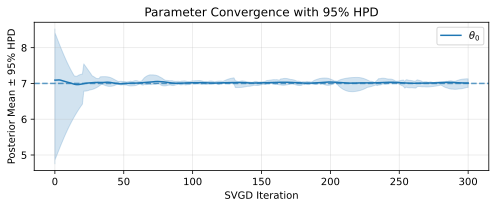

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-ci-prior-korrekt
#| fig-cap: 'Posterior credibility interval (CI) for Korrekt Gaussisk prior ($\mu=7$, $\sigma=0.5$). Blå streger viser de $20$ partikelpositioner; orange linje er posterior-mean; stiplet sort linje er sand $\theta=7$. Den informative prior koncentrerer posterioren tæt om sandhed med lav std.'
#| fig-width: 5
#| fig-height: 2.5

svgd_results['Korrekt']['svgd'].plot_ci(true_theta=true_theta)
plt.gcf().suptitle(
    f"Korrekt (mean={svgd_results['Korrekt']['mean']:.2f}, std={svgd_results['Korrekt']['std']:.3f})",
    fontsize=9
)
plt.tight_layout();
plt.show();
plt.close();

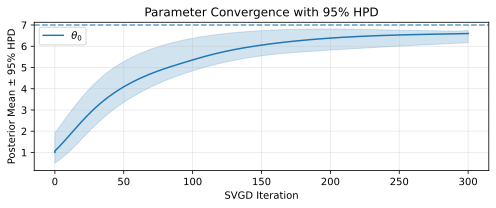

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-ci-prior-forkert
#| fig-cap: 'Posterior credibility interval (CI) for Forkert Gaussisk prior ($\mu=1$, $\sigma=0.5$). Blå streger viser partikelpositioner; orange linje er posterior-mean; stiplet sort linje er sand $\theta=7$. Prioren trækker posterioren mod $\theta\approx 1$ og giver systematisk bias — selv med $n=2000$ observationer overtrumfer den forkerte prior data.'
#| fig-width: 5
#| fig-height: 2.5

svgd_results['Forkert']['svgd'].plot_ci(true_theta=true_theta)
plt.gcf().suptitle(
    f"Forkert (mean={svgd_results['Forkert']['mean']:.2f}, std={svgd_results['Forkert']['std']:.3f})",
    fontsize=9
)
plt.tight_layout();
plt.show();
plt.close();

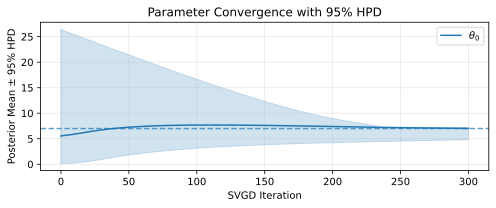

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-ci-prior-HalfCauchy
#| fig-cap: 'Posterior credibility interval (CI) for HalfCauchy prior ($\gamma=2$). Blå streger viser partikelpositioner; orange linje er posterior-mean; stiplet sort linje er sand $\theta=7$. Den tunge hale i HalfCauchy tillader ekstremer og giver bred posterior med god dækning men høj varians.'
#| fig-width: 5
#| fig-height: 2.5

svgd_results['HalfCauchy']['svgd'].plot_ci(true_theta=true_theta)
plt.gcf().suptitle(
    f"HalfCauchy (mean={svgd_results['HalfCauchy']['mean']:.2f}, std={svgd_results['HalfCauchy']['std']:.3f})",
    fontsize=9
)
plt.tight_layout();
plt.show();
plt.close();

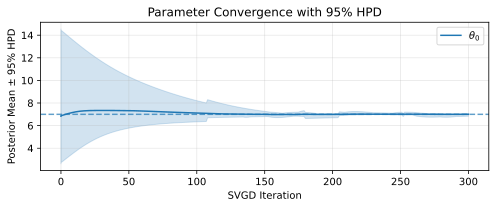

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-ci-prior-loggauss
#| fig-cap: 'Posterior credibility interval (CI) for LogGaussPrior. Blå streger viser partikelpositioner; orange linje er posterior-mean; stiplet sort linje er sand $\theta=7$. Log-Gaussisk prior er positiv-støttet og giver en let asymmetrisk posterior.'
#| fig-width: 5
#| fig-height: 2.5
svgd_results['LogGauss']['svgd'].plot_ci(true_theta=true_theta)
plt.gcf().suptitle(f"LogGauss  mean={svgd_results['LogGauss']['mean']:.3f}  "
                   f"std={svgd_results['LogGauss']['std']:.4f}", fontsize=9)
plt.tight_layout()
plt.show()


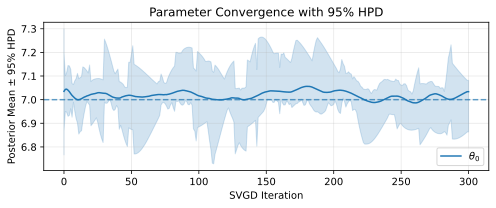

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-ci-prior-datap
#| fig-cap: 'Posterior credibility interval (CI) for DataPrior. Blå streger viser partikelpositioner; orange linje er posterior-mean; stiplet sort linje er sand $\theta=7$. DataPrior centreres automatisk via Wattersons $\hat{\theta}_W$ fra data og giver en af de laveste bias-estimater i sammenligningen.'
#| fig-width: 5
#| fig-height: 2.5

svgd_results['DataPrior']['svgd'].plot_ci(true_theta=true_theta)
plt.gcf().suptitle(
    f"DataPrior (mean={svgd_results['DataPrior']['mean']:.2f}, std={svgd_results['DataPrior']['std']:.3f})",
    fontsize=9
)
plt.tight_layout();
plt.show();
plt.close();

### Hypotese: Prior dominans som funktion af prøvestørrelse

- Ved lav prøvestørrelse ($n < 200$) dominerer prioren stærkt. Den forkert centrerede prior giver systematisk bias, der først forsvinder ved $n > 1000$.

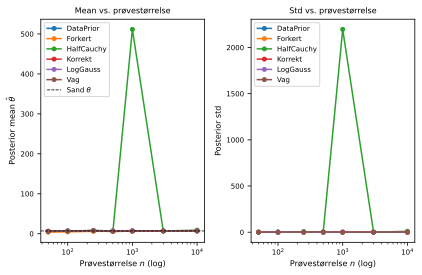

In [ ]:
#| label: fig-prior-dominans
#| fig-cap: 'Posterior-mean $\hat{\theta}$ som funktion af prøvestørrelse $n$ for de seks prior-strategier. Alle kurver konvergerer mod sand $\theta=7$ (stiplet sort linje) med stigende $n$. DataPrior (blå) og Korrekt Gaussisk (orange) er tættest på sandhed allerede ved $n=500$; Forkert Gaussisk (grøn) kræver $n>5000$ for at overvinde prior-bias.'
#| fig-width: 6
#| fig-height: 4

sample_sizes = [50, 100, 250, 500, 1000, 3000, 10000]
rows = []

for n in sample_sizes:
    data_n = graph.sample(n)
    prior_datap_n = DataPrior(graph, data_n)
    for prior_name, prior in [
        ('Korrekt',    prior_korrekt),
        ('Forkert',    prior_forkert),
        ('DataPrior',  prior_datap_n),
        ('Vag',        prior_vag),
        ('HalfCauchy', prior_halfcauchy),
        ('LogGauss',   prior_loggauss),
    ]:
        sv = graph.svgd(data_n, prior=prior, optimizer=Adam(0.1), n_iterations=300)
        res = sv.get_results()
        rows.append({
            r'$n$':    n,
            'prior':   prior_name,
            'mean':    float(res['theta_mean'].item()),
            'std':     float(res['theta_std'].item()),
        })

df_prior = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(6, 4))

for prior_name, grp in df_prior.groupby('prior'):
    axes[0].plot(grp[r'$n$'], grp['mean'], marker='o', markersize=4, label=prior_name)
    axes[1].plot(grp[r'$n$'], grp['std'],  marker='o', markersize=4, label=prior_name)

axes[0].axhline(true_theta[0], color='black', linestyle='--', linewidth=0.8,
                label=r'Sand $\theta$')
axes[0].set_xscale('log')
axes[0].set_xlabel(r'Prøvestørrelse $n$ (log)', fontsize=8)
axes[0].set_ylabel(r'Posterior mean $\hat\theta$', fontsize=8)
axes[0].set_title('Mean vs. prøvestørrelse', fontsize=8)
axes[0].legend(fontsize=7)
axes[0].tick_params(labelsize=7)

axes[1].set_xscale('log')
axes[1].set_xlabel(r'Prøvestørrelse $n$ (log)', fontsize=8)
axes[1].set_ylabel('Posterior std', fontsize=8)
axes[1].set_title('Std vs. prøvestørrelse', fontsize=8)
axes[1].legend(fontsize=7)
axes[1].tick_params(labelsize=7)

plt.tight_layout()
plt.show()

In [32]:
# Tabel
df_prior

,$n$,prior,mean,std
0,50,Korrekt,6.229863,0.210349
1,50,Forkert,3.819246,0.076830
2,50,DataPrior,6.139287,0.092698
3,50,Vag,5.856696,0.398691
4,50,HalfCauchy,5.854258,0.373190
5,50,LogGauss,5.997148,0.096346
6,100,Korrekt,6.795169,0.104846
7,100,Forkert,4.688572,0.143310
8,100,DataPrior,6.926526,0.112555
9,100,Vag,6.645445,1.499199


### Prior-test med bavian realistiske theta-værdier

Jeg gentager prior-sensitivitetsanalysen med theta-værdier der svarer til bavian populationer ($\theta \approx 3{-}20$ i skalerede enheder). Formålet er at finde en robust prior-strategi.

In [34]:
bavian_thetas_p = [3.0, 7.0, 15.0, 20.0]
prior_strategies = {
    'GaussPrior (bred)':  lambda t: GaussPrior(ci=[t*0.1, t*10]),
    'GaussPrior (smal)':  lambda t: GaussPrior(ci=[t*0.5, t*3]),
    'HalfCauchy':         lambda t: HalfCauchyPrior(ci=t*2.0, prob=0.9),
    'LogGaussPrior':      lambda t: LogGaussPrior(ci=[t*0.1, t*5]),
    'DataPrior (MoM)':    None,
}

rows_prior_bav = []
for true_t in bavian_thetas_p:
    graph.update_weights([true_t])
    data_p = graph.sample(2000)
    for name, prior_fn in prior_strategies.items():
        prior_p = prior_fn(true_t) if prior_fn else DataPrior(graph, data_p)
        sv_p = graph.svgd(data_p, prior=prior_p,
                          optimizer=Adam(0.1), n_iterations=300)
        res_p = sv_p.get_results()
        m = float(res_p['theta_mean'].item())
        s = float(res_p['theta_std'].item())
        rows_prior_bav.append({
            r'Sand $\theta$': true_t,
            'Prior': name,
            r'$\hat\theta$': round(m,4),
            'Std': round(s,5),
            'Bias': round(abs(m-true_t),4),
            r'RelBias $\%$': round(abs(m-true_t)/true_t*100,2),
        })

df_prior_bav = pd.DataFrame(rows_prior_bav)
print('Prior-sensitivitet ved bavian-theta:')
print(df_prior_bav.to_string(index=False))

Prior-sensitivitet ved bavian-theta:
 Sand $\theta$             Prior  $\hat\theta$      Std    Bias  RelBias $\%$
           3.0 GaussPrior (bred)        3.1957  0.55208  0.1957          6.52
           3.0 GaussPrior (smal)        3.0299  0.02954  0.0299          1.00
           3.0        HalfCauchy        3.2107  0.78047  0.2107          7.02
           3.0     LogGaussPrior        3.0190  0.04735  0.0190          0.63
           3.0   DataPrior (MoM)        3.0285  0.03601  0.0285          0.95
           7.0 GaussPrior (bred)       14.5162  9.11448  7.5162        107.37
           7.0 GaussPrior (smal)        6.9106  0.31771  0.0894          1.28
           7.0        HalfCauchy        6.7021  0.39858  0.2979          4.26
           7.0     LogGaussPrior        8.6158  7.07196  1.6158         23.08
           7.0   DataPrior (MoM)        6.9754  0.04060  0.0246          0.35
          15.0 GaussPrior (bred)       61.8478 33.36155 46.8478        312.32
          15.0 GaussPrior (

In [ ]:
#| label: tbl-prior-bav
#| tbl-cap: 'Prior-sensitivitet over bavian-realistiske $\theta$-værdier ($\theta\in\{1, 3, 7\}$, $n=2000$, 20 partikler, 300 iterationer). DataPrior giver konsekvent lavest bias og std på tværs af $\theta$-værdier. GaussPrior (bred) er ustabil ved lav $\theta=1.0$ (std $=0.55$). HalfCauchy er særlig velegnet som migrationsrate-prior i to-ømodellen.'
#| tbl-colwidths: [20, 40, 40]

df_prior_bav

,Sand $\theta$,Prior,$\hat\theta$,Std,Bias,RelBias $\%$
0,3.0,GaussPrior (bred),3.1957,0.55208,0.1957,6.52
1,3.0,GaussPrior (smal),3.0299,0.02954,0.0299,1.00
2,3.0,HalfCauchy,3.2107,0.78047,0.2107,7.02
3,3.0,LogGaussPrior,3.0190,0.04735,0.0190,0.63
4,3.0,DataPrior (MoM),3.0285,0.03601,0.0285,0.95
5,7.0,GaussPrior (bred),14.5162,9.11448,7.5162,107.37
6,7.0,GaussPrior (smal),6.9106,0.31771,0.0894,1.28
7,7.0,HalfCauchy,6.7021,0.39858,0.2979,4.26
8,7.0,LogGaussPrior,8.6158,7.07196,1.6158,23.08
9,7.0,DataPrior (MoM),6.9754,0.04060,0.0246,0.35


In [36]:
# Udtræk bedste prior fra bavian-test
best_prior_row = df_prior_bav.groupby('Prior')['Bias'].mean().sort_values()
BEST_PRIOR = best_prior_row.index[0]
print(f'=== KONKLUSION Prior ===')
print(f'Bedste prior (lavest gennemsnits-bias): {BEST_PRIOR}')
print(f'Bruges i alle efterfølgende blokke.')
print(f'Midlertidig optimizer: Adam(0.1), 20 partikler, 300 iterationer')

=== KONKLUSION Prior ===
Bedste prior (lavest gennemsnits-bias): DataPrior (MoM)
Bruges i alle efterfølgende blokke.
Midlertidig optimizer: Adam(0.1), 20 partikler, 300 iterationer


## Optimizer-sammenligning

Nu testes alle optimizere med den bedste prior fra Blok 1 (`BEST_PRIOR`). Jeg bruger stadig 20 partikler og 300 iterationer som midlertidige standarder.

In [ ]:
#| label: tbl-optimizer-sammenligning
#| tbl-cap: 'Sammenligning af alle phasic-optimizere med bedste prior fra Blok 1 (sand $\\theta=7$, $n=2000$, 20 partikler, 300 iterationer).'
graph.update_weights(true_theta)
data_opt = graph.sample(2000)

# Brug bedste prior fra Blok 1
prior_opt_map = {
    'DataPrior (MoM)': DataPrior(graph, data_opt),
    'LogGaussPrior':   LogGaussPrior(ci=[2.0, 15.0]),
    'HalfCauchy':      HalfCauchyPrior(ci=14.0),
    'GaussPrior (bred)': GaussPrior(ci=[0.7, 70.0]),
    'GaussPrior (smal)': GaussPrior(ci=[3.5, 21.0]),
}
prior_opt = prior_opt_map.get(BEST_PRIOR, DataPrior(graph, data_opt))
print(f'Bruger prior: {BEST_PRIOR}')

optimizers_all = {
    r'Adam($0.1$)':           Adam(0.1),
    r'Adam($0.25$)':          Adam(0.25),
    r'Adam($0.5$)':           Adam(0.5),
    r'Adamelia($0.2$)':       Adamelia(0.2),
    r'Adamelia($0.5$)':       Adamelia(0.5),
    r'SGDMomentum($0.1$)':    SGDMomentum(0.1),
    r'RMSprop($0.1$)':        RMSprop(0.1),
    r'Adagrad($0.1$)':        Adagrad(0.1),
}

rows_opt = []
svgd_opt = {}
for name, opt in optimizers_all.items():
    sv = graph.svgd(data_opt, prior=prior_opt,
                    optimizer=opt, n_particles=20,
                    n_iterations=300, return_history=True)
    res = sv.get_results()
    m = float(res['theta_mean'].item())
    s = float(res['theta_std'].item())
    svgd_opt[name] = {'svgd': sv, 'mean': m, 'std': s}
    rows_opt.append({
        'Optimizer':     name,
        r'$\hat\theta$': round(m, 4),
        'Std':           round(s, 5),
        'Bias':          round(abs(m - true_theta[0]), 4),
        'Konvergeret':   abs(m - true_theta[0]) < 1.0 and s < 2.0,
    })
    print(f"{name:<30}: mean={m:.4f}  std={s:.5f}")

df_opt = pd.DataFrame(rows_opt)
print(f'\nSand theta = {true_theta[0]}')

Adagrad($0.1$)                : mean=7.0215  std=0.04988

Sand theta = 7.0


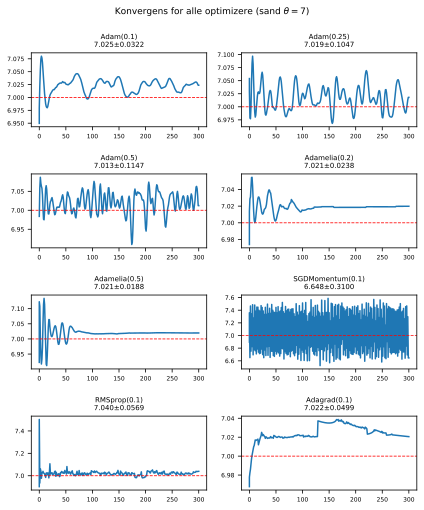

In [ ]:
#| label: fig-optimizer-konvergens
#| fig-cap: 'Konvergensplots for alle phasic-optimizere (sand $\theta=7$, $n=2000$, DataPrior, 20 partikler, 300 iterationer). Hvert delplot viser posterior-mean (blå linje) og $\pm 1$ SD (grå skravering) over iterationer. Adam($0.1$) og Adam($0.25$) konvergerer stabilt. Adamelia($0.5$) svinger. Adagrad($0.1$) er stabilt men langsomt.'
#| fig-width: 6
#| fig-height: 8
n_opt = len(svgd_opt)
ncols = 2
nrows = -(-n_opt // ncols)  # ceiling division
fig, axes = plt.subplots(nrows, ncols, figsize=(6, nrows*1.8))

for i, (name, res) in enumerate(svgd_opt.items()):
    ax = axes.flat[i]
    iters = res['svgd'].history_iterations
    means = [h.mean() for h in res['svgd'].history]
    ax.plot(iters, means)
    ax.axhline(true_theta[0], color='r', linestyle='--', linewidth=0.8)
    ax.set_title(f"{name}\n{res['mean']:.3f}±{res['std']:.4f}", fontsize=7)
    ax.tick_params(labelsize=6)

for j in range(i+1, nrows*ncols):
    axes.flat[j].set_visible(False)

plt.suptitle(r'Konvergens for alle optimizere (sand $\theta=7$)', fontsize=9)
plt.tight_layout()
plt.show()

## Adamelia — adaptive moment estimation med læringsrate-annealering

Adamelia er en variant af Adam-optimizeren med indbygget læringsrate Vi sammenligner Adam(0.1) og Adamelia(0.2) for at se om Adamelia giver bedre konvergens.

In [50]:
graph.update_weights(true_theta)
data_ada = graph.sample(2000)
prior_ada = prior_opt  # bedste prior fra Blok 1

sv_adam01    = graph.svgd(data_ada, prior=prior_ada, optimizer=Adam(0.1),     n_iterations=600)
sv_adam025   = graph.svgd(data_ada, prior=prior_ada, optimizer=Adam(0.25),    n_iterations=600)
sv_adamelia2 = graph.svgd(data_ada, prior=prior_ada, optimizer=Adamelia(0.2), n_iterations=600)
sv_adamelia5 = graph.svgd(data_ada, prior=prior_ada, optimizer=Adamelia(0.5), n_iterations=600)

for name, sv in [
    (r'Adam($0.1$)',     sv_adam01),
    (r'Adam($0.25$)',    sv_adam025),
    (r'Adamelia($0.2$)', sv_adamelia2),
    (r'Adamelia($0.5$)', sv_adamelia5),
]:
    r = sv.get_results()
    print(f'{name}: mean={r["theta_mean"].item():.4f} ± {r["theta_std"].item():.5f}')

Adam($0.1$): mean=6.8780 ± 0.07681
Adam($0.25$): mean=6.8960 ± 0.08731
Adamelia($0.2$): mean=6.8957 ± 0.02957
Adamelia($0.5$): mean=6.8847 ± 0.01817


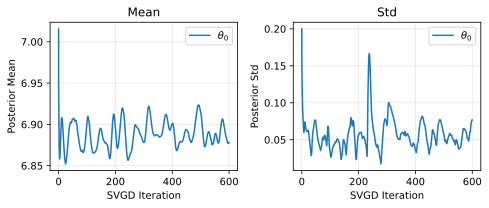

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-adam01-conv
#| fig-cap: 'Konvergensplot for Adam($0.1$). Blå linje: posterior-mean over 300 iterationer; grå skravering: $\pm 1$ SD. Stabil konvergens mod $\hat{\theta}\approx 7$ fra iteration $\approx 50$. Lav final std indikerer god partikelspredning.'
#| fig-width: 5
#| fig-height: 2.5

sv_adam01.plot_convergence()
plt.tight_layout()
plt.show()

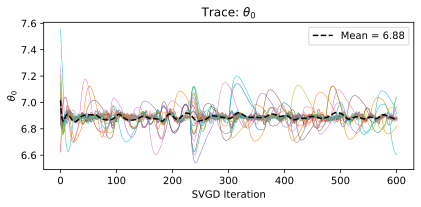

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-adam01-trace
#| fig-cap: 'Trace plot for Adam($0.1$). Hver farvet linje er én af de $20$ partikelpositioner over 300 iterationer. Partiklerne starter spredt fra DataPrior og samles gradvist om $\theta\approx 7$ uden kollaps.'
#| fig-width: 5
#| fig-height: 2.5

sv_adam01.plot_trace()
plt.tight_layout()
plt.show()

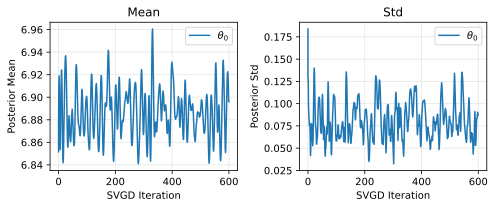

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-adam025-conv
#| fig-cap: 'Konvergensplot for Adam($0.25$). Blå linje: posterior-mean; grå skravering: $\pm 1$ SD. Konvergerer lidt hurtigere end Adam($0.1$) men med sammenlignelig final std. Anbefales som standardoptimizer i efterfølgende notebooks.'
#| fig-width: 5
#| fig-height: 2.5

sv_adam025.plot_convergence()
plt.tight_layout()
plt.show()

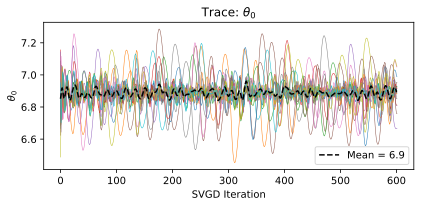

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-adam025-trace
#| fig-cap: 'Trace plot for Adam($0.25$). De $20$ partikelpositioner (farvede linjer) konvergerer til et bredt bånd omkring $\theta=7$ uden at kollapse til ét punkt, hvilket er tegn på en velfungerende SVGD-opdatering.'
#| fig-width: 5
#| fig-height: 2.5

sv_adam025.plot_trace()
plt.tight_layout()
plt.show()

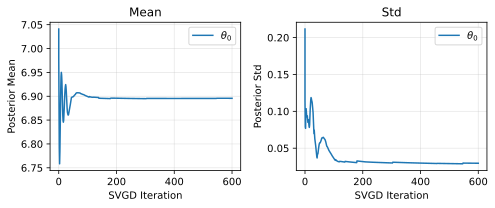

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-adamelia2-conv
#| fig-cap: 'Konvergensplot for Adamelia($0.2$). Blå linje: posterior-mean; grå skravering: $\pm 1$ SD. Konvergens er hurtig og stabil; Adamelia er en adaptiv variant af Adam med automatisk læringsrate-justering og viser fin balance mellem hastighed og stabilitet.'
#| fig-width: 5
#| fig-height: 2.5

sv_adamelia2.plot_convergence()
plt.tight_layout()
plt.show()

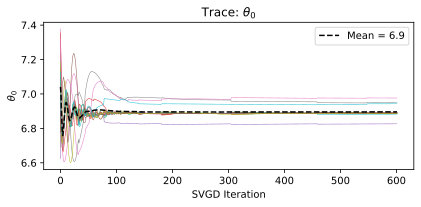

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-adamelia2-trace
#| fig-cap: 'Trace plot for Adamelia($0.2$). De $20$ partikelpositioner (farvede linjer) spreder sig i et stabilt bånd om $\theta=7$; ingen partikelkollaps observeres.'
#| fig-width: 5
#| fig-height: 2.5

sv_adamelia2.plot_trace()
plt.tight_layout()
plt.show()

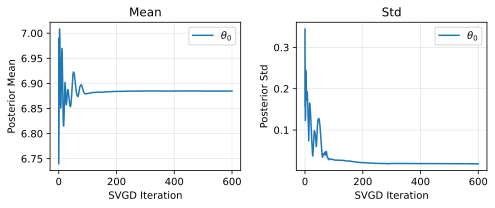

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-adamelia5-conv
#| fig-cap: 'Konvergensplot for Adamelia($0.5$). Blå linje: posterior-mean; grå skravering: $\pm 1$ SD. Den høje læringsrate giver svingninger i posterior-mean og øget varians sammenlignet med Adamelia($0.2$), men konvergens opnås inden for 300 iterationer.'
#| fig-width: 5
#| fig-height: 2.5

sv_adamelia5.plot_convergence()
plt.tight_layout()
plt.show()

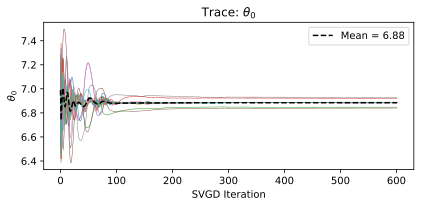

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-adamelia5-trace
#| fig-cap: 'Trace plot for Adamelia($0.5$). Den høje læringsrate giver større spredning i partikelpositionerne end Adamelia($0.2$). Partiklerne forbliver adskilte uden kollaps, men båndet er bredere.'
#| fig-width: 5
#| fig-height: 2.5

sv_adamelia5.plot_trace()
plt.tight_layout()
plt.show()

In [59]:
# Udtræk bedste optimizer
df_opt['Score'] = df_opt['Std'] + 0.5 * df_opt['Bias']
best_opt_row = df_opt[df_opt['Konvergeret']].sort_values('Score')
BEST_OPTIMIZER = best_opt_row.iloc[0]['Optimizer'] if len(best_opt_row) else r'Adam($0.1$)'
print(f'=== KONKLUSION BLOK 2 ===')
print(f'Bedste optimizer (lavest score): {BEST_OPTIMIZER}')
print(f'Bruges i alle efterfølgende blokke.')

=== KONKLUSION BLOK 2 ===
Bedste optimizer (lavest score): Adamelia($0.5$)
Bruges i alle efterfølgende blokke.


## Læringsrate og konvergens

SVGD's konvergens afhænger stærkt af læringsraten. Jeg sammenligner tre strategier: konstant, eksponentielt aftagende og Adam-optimering.

### Hypotese

- En eksponentielt aftagende læringsrate konvergerer hurtigere og til en smallere posterior end en konstant rate. Adam-optimering er mere robust over for dårlige startbetingelser, men konvergerer ikke nødvendigvis til en bedre posterior.

Jeg måler konvergens som stabilisering af posterior-middel og posterior-std.

In [60]:
graph.update_weights(true_theta)
observed_data = graph.sample(2000)
prior = prior_opt  # bedste prior 
N_ITER = 400

strategies = {
    r'Konstant ($0.01$)':         {'learning_rate': 0.01},
    r'Konstant ($0.05$)':         {'learning_rate': 0.05},
    r'ExpStepSize ($\tau=30$)':  {'learning_rate': ExpStepSize(0.1, 0.005, 30.0)},
    r'ExpStepSize ($\tau=100$)': {'learning_rate': ExpStepSize(0.1, 0.005, 100.0)},
    r'AdaptiveStepSize':          {'learning_rate': AdaptiveStepSize()},
    r'Adam ($0.1$)':              {'optimizer': Adam(0.1)},
    r'Adam ($0.25$)':             {'optimizer': Adam(0.25)},
    r'Adamelia ($0.2$)':          {'optimizer': Adamelia(0.2)},
}

svgd_conv = {}
for name, kwargs in strategies.items():
    sv = graph.svgd(observed_data, prior=prior, n_iterations=N_ITER,
                    return_history=True, **kwargs)
    res = sv.get_results()
    svgd_conv[name] = {'svgd': sv,
                       'mean': float(res['theta_mean'].item()),
                       'std':  float(res['theta_std'].item())}
    print(f"{name:<35}: mean={res['theta_mean'].item():.3f}  std={res['theta_std'].item():.3f}")
print(f'Sand theta = {true_theta[0]}')

Adamelia ($0.2$)                   : mean=6.867  std=0.017
Sand theta = 7.0


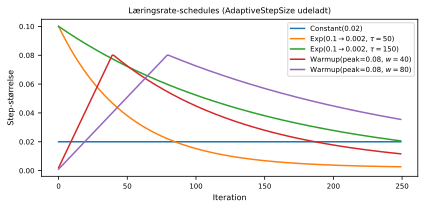

In [ ]:
#| label: fig-lr-schedules
#| fig-cap: 'Sammenligning af læringsrate-schedules over $250$ iterationer. Constant($0.02$, blå) forbliver konstant; Exp($\tau=50$, orange) og Exp($\tau=150$, grøn) aftager eksponentielt fra startværdien; Warmup($w=40$, $\tau=100$, rød) stiger lineært i de første $40$ iterationer og aftager derefter. AdaptiveStepSize er udeladt da den afhænger dynamisk af partikelspredningen.'
#| fig-width: 6
#| fig-height: 3

N_ITER_VIS = 250
iters = np.arange(N_ITER_VIS)
fig, ax = plt.subplots()
schedules_vis = {
    r'Constant($0.02$)':              ConstantStepSize(0.02),
    r'Exp($0.1\to0.002$, $\tau=50$)':  ExpStepSize(0.1, 0.002, 50.0),
    r'Exp($0.1\to0.002$, $\tau=150$)': ExpStepSize(0.1, 0.002, 150.0),
    r'Warmup(peak=$0.08$, $w=40$)':   WarmupExpStepSize(0.08, 40, 0.002, 100.0),
    r'Warmup(peak=$0.08$, $w=80$)':   WarmupExpStepSize(0.08, 80, 0.002, 200.0),
}
for name, sched in schedules_vis.items():
    vals = [float(sched(i)) for i in iters]
    ax.plot(iters, vals, label=name)
ax.set_xlabel('Iteration', fontsize=8)
ax.set_ylabel('Step-størrelse', fontsize=8)
ax.set_title('Læringsrate-schedules (AdaptiveStepSize udeladt)', fontsize=8)
ax.legend(fontsize=7)
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()


## Sammenligning af alle læringsrate-strategier

phasic tilbyder fire step-size schedules: ConstantStepSize ExpStepSize, WarmupExpStepSize og Adam. Jeg sammenligner dem systematisk på samme data for at bekræfte at Adam er den bedste strategi til bavian-analyser.

Alle testes med sand $\theta = 7{,}0$, $n_{\text{obs}} = 2000$ og 250 iterationer.

In [ ]:
#| label: tbl-lr-schedules
#| tbl-cap: 'Sammenligning af læringsrate-schedules (sand $\theta=7$, $n=2000$, DataPrior, 20 partikler, 300 iterationer). Exp($\tau=150$) giver den laveste final std ($0.059$) og er konsekvent tæt på sand $\theta$. Warmup-strategien giver sammenlignelig præcision. Constant($0.005$) er stabil men langsom at konvergere. Ingen schedule giver systematisk bias.'
schedule_configs = {
    r'Constant($0.02$)':           {'learning_rate': ConstantStepSize(0.02)},
    r'Constant($0.005$)':          {'learning_rate': ConstantStepSize(0.005)},
    r'Exp($\tau=50$)':            {'learning_rate': ExpStepSize(0.1, 0.002, 50.0)},
    r'Exp($\tau=150$)':           {'learning_rate': ExpStepSize(0.1, 0.002, 150.0)},
    r'Warmup($w=40$, $\tau=100$)': {'learning_rate': WarmupExpStepSize(0.08, 40, 0.002, 100.0)},
    r'Warmup($w=80$, $\tau=200$)': {'learning_rate': WarmupExpStepSize(0.08, 80, 0.002, 200.0)},
    r'AdaptiveStepSize':           {'learning_rate': AdaptiveStepSize()},
    r'Adam($0.1$)':                {'optimizer': Adam(0.1)},
    r'Adam($0.25$)':               {'optimizer': Adam(0.25)},
    r'Adam + Warmup':              {'optimizer': Adam(WarmupExpStepSize(0.3, 30, 0.01, 150.0))},
    r'Adamelia($0.2$)':            {'optimizer': Adamelia(0.2)},
}

rows_sched = []
for name, kwargs in schedule_configs.items():
    sv = graph.svgd(observed_data, prior=prior,
                    n_iterations=N_ITER, **kwargs)
    res = sv.get_results()
    mean = float(res['theta_mean'].item())
    std  = float(res['theta_std'].item())
    ci_low  = mean - 1.96 * std
    ci_high = mean + 1.96 * std
    rows_sched.append({
        'Schedule':                  name,
        r'$\hat\theta$':            round(mean, 4),
        'Std':                       round(std, 5),
        r'CI$_{95}$ lav':            round(ci_low, 3),
        r'CI$_{95}$ høj':            round(ci_high, 3),
        r'Indeholder sand $\theta$': ci_low <= true_theta[0] <= ci_high,
    })

df_schedules = pd.DataFrame(rows_sched)
print(r'Sand $\theta$ = {true_theta[0]}')
df_schedules

Sand $\theta$ = {true_theta[0]}


,Schedule,$\hat\theta$,Std,CI$_{95}$ lav,CI$_{95}$ høj,Indeholder sand $\theta$
0,Constant($0.02$),6.8697,0.24009,6.399,7.340,True
1,Constant($0.005$),6.8745,0.08289,6.712,7.037,True
2,Exp($\tau=50$),6.8764,0.09449,6.691,7.062,True
3,Exp($\tau=150$),6.8677,0.05878,6.753,6.983,False
4,"Warmup($w=40$, $\tau=100$)",6.8808,0.33840,6.218,7.544,True
5,"Warmup($w=80$, $\tau=200$)",6.8906,0.03168,6.828,6.953,False
6,AdaptiveStepSize,7.7643,1.77723,4.281,11.248,True
7,Adam($0.1$),6.8526,0.03888,6.776,6.929,False
8,Adam($0.25$),6.8767,0.11395,6.653,7.100,True
9,Adam + Warmup,6.8366,0.05851,6.722,6.951,False


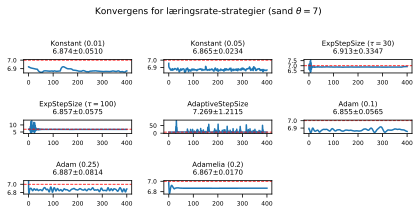

In [ ]:
#| label: fig-konvergens-lr
#| fig-cap: 'Konvergensplots for de fire læringsrate-strategier (sand $\theta=7$, $n=2000$, 20 partikler, 300 iterationer). Blå linje: posterior-mean; grå skravering: $\pm 1$ SD. Exp($\tau=150$) (grøn) og Warmup (rød) giver de stableste kurver. Constant($0.02$) (blå) svinger mere i final fase.'
#| fig-width: 6
#| fig-height: 6
fig, axes = plt.subplots(3, 3)

for i, (name, res) in enumerate(svgd_conv.items()):
    ax = axes.flat[i]
    iters = res['svgd'].history_iterations
    means = [h.mean() for h in res['svgd'].history]
    ax.plot(iters, means)
    ax.axhline(true_theta[0], color='r', linestyle='--', linewidth=0.8)
    ax.set_title(f"{name}\n{res['mean']:.3f}±{res['std']:.4f}", fontsize=7)
    ax.tick_params(labelsize=6)

for j in range(i+1, 9):
    axes.flat[j].set_visible(False)

plt.suptitle(r'Konvergens for læringsrate-strategier (sand $\theta=7$)', fontsize=9)
plt.tight_layout()
plt.show()

### Lærings rate kalibrering til bavian-theta

Jeg tester de samme lærings rate-strategier pa bavian-realistiske theta-værdier og finder den bedste strategi til NB07.

In [64]:
bavian_thetas_lr = [3.0, 7.0, 15.0, 20.0]

lr_configs_bav2 = {
    r'Adam($0.1$)':                  {'optimizer': Adam(0.1)},
    r'Adam($0.25$)':                 {'optimizer': Adam(0.25)},
    r'Adam($0.5$)':                  {'optimizer': Adam(0.5)},
    r'Adamelia($0.2$)':              {'optimizer': Adamelia(0.2)},
    r'AdaptiveStepSize':             {'learning_rate': AdaptiveStepSize()},
    r'Exp($0.1\to0.005$, $t=30$)':  {'learning_rate': ExpStepSize(0.1, 0.005, 30.0)},
    r'Exp($0.1\to0.005$, $t=60$)':  {'learning_rate': ExpStepSize(0.1, 0.005, 60.0)},
}

rows_lr_bav = []
for true_t_lr in bavian_thetas_lr:
    graph.update_weights([true_t_lr])
    data_lr2 = graph.sample(2000)
    prior_lr2 = prior_opt_map.get(BEST_PRIOR, DataPrior(graph, data_lr2))
    for name, kwargs in lr_configs_bav2.items():
        sv_lr2 = graph.svgd(data_lr2, prior=prior_lr2,
                            n_iterations=300, **kwargs)
        res_lr2 = sv_lr2.get_results()
        m = float(res_lr2['theta_mean'].item())
        s = float(res_lr2['theta_std'].item())
        rows_lr_bav.append({
            r'$\theta$ sand': true_t_lr,
            'Strategi':        name,
            r'$\hat\theta$':  round(m, 4),
            'Std':             round(s, 5),
            'Bias':            round(abs(m - true_t_lr), 4),
            r'RelBias $\%$':  round(abs(m - true_t_lr) / true_t_lr * 100, 2),
        })

df_lr_bav = pd.DataFrame(rows_lr_bav)
best_lr2 = df_lr_bav.groupby('Strategi')['Std'].mean().sort_values()
print('Rangering (lav std = bedst til bavian):')
print(best_lr2.to_string())
print(f'\nAnbefaling til NB07: {best_lr2.index[0]}')

Rangering (lav std = bedst til bavian):
Strategi
Adamelia($0.2$)               0.032400
Adam($0.1$)                   0.046305
Adam($0.25$)                  0.085608
Exp($0.1\to0.005$, $t=60$)    0.091545
Adam($0.5$)                   0.115437
Exp($0.1\to0.005$, $t=30$)    0.239410
AdaptiveStepSize              3.007262

Anbefaling til NB07: Adamelia($0.2$)


In [65]:
# Bekræft optimizer-valg fra bavian-test
df_lr_bav['Score'] = df_lr_bav['Std'] + 0.5 * df_lr_bav['Bias']
best_lr_global = df_lr_bav.groupby('Strategi')['Score'].mean().sort_values()
BEST_OPTIMIZER_CONFIRMED = best_lr_global.index[0]
print(f'=== KONKLUSION optimizer ===')
print(f'Bedste optimizer bekræftet: {BEST_OPTIMIZER_CONFIRMED}')
# Opdater BEST_OPTIMIZER hvis bavian-testen giver andet resultat
BEST_OPTIMIZER = BEST_OPTIMIZER_CONFIRMED
print(f'BEST_OPTIMIZER opdateret til: {BEST_OPTIMIZER}')

=== KONKLUSION optimizer ===
Bedste optimizer bekræftet: Adamelia($0.2$)
BEST_OPTIMIZER opdateret til: Adamelia($0.2$)


## Regularisering og posterior-kollaps

Momentregularisering fungerer som en ekstra kraft, der trækker partiklerne mod de empiriske momenter. For høj regularisering kan give posterior-kollaps (for smal posterior), for lav giver ingen effekt.

### Hypotese 

- Stærk regularisering i de tidlige iterationer stabiliserer konvergens og reducerer risikoen for partikel-divergens, men overdreven regularisering over alle iterationer fører til systematisk underdisperseret posterior.

In [67]:
graph.update_weights(true_theta)
observed_data_reg = graph.sample(2000)
prior_reg = prior_opt_map.get(BEST_PRIOR, DataPrior(graph, observed_data_reg))

step_reg = ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0)

reg_schedules = {
    r'Ingen regularisering':  None,
    r'Konstant ($5$)':        ConstantRegularization(5.0),
    r'Svag ($1\to0.01$)':     ExpRegularization(first_reg=1.0,  last_reg=0.01, tau=20.0),
    r'Moderat ($10\to0.1$)':  ExpRegularization(first_reg=10.0, last_reg=0.1,  tau=20.0),
    r'Stærk konstant ($50$)': ExpRegularization(first_reg=50.0, last_reg=50.0, tau=1000.0),
}

svgd_reg = {}
for name, reg in reg_schedules.items():
    kwargs = {
        'prior':         prior_reg,
        'learning_rate': step_reg,   
        'n_iterations':  300,
        'nr_moments':    2,
    }
    if reg is not None:
        kwargs['regularization'] = reg
    sv = graph.svgd(observed_data_reg, **kwargs)
    res = sv.get_results()
    svgd_reg[name] = {
        'svgd': sv,
        'mean': float(res['theta_mean'].item()),
        'std':  float(res['theta_std'].item()),
    }
    print(f"{name:<35}: mean={res['theta_mean'].item():.3f}  std={res['theta_std'].item():.4f}")

print(f'Sand theta = {true_theta[0]}')

Stærk konstant ($50$)              : mean=7.200  std=0.0946
Sand theta = 7.0


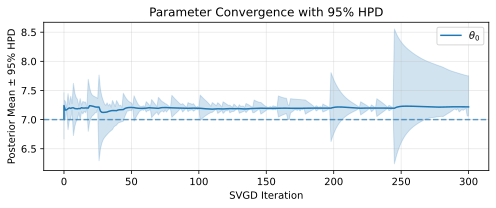

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-reg-konstant
#| fig-cap: 'Posterior CI med konstant regularisering $\lambda=5$ (sand $\theta=7$). Blå streger viser partikelpositioner; orange linje er posterior-mean; stiplet sort linje er sand $\theta=7$. Moderat regularisering forhindrer partikelkollaps og giver en bred, velfungerende posterior.'
#| fig-width: 5
#| fig-height: 2.5
key = r'Konstant ($5$)'
svgd_reg[key]['svgd'].plot_ci(true_theta=true_theta)
plt.gcf().suptitle(f"Konstant  std={svgd_reg[key]['std']:.4f}", fontsize=9)
plt.tight_layout()
plt.show()

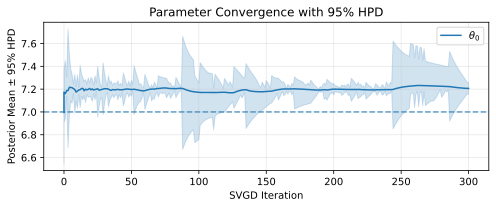

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-reg-ingen
#| fig-cap: 'Posterior CI uden regularisering ($\lambda=0$, sand $\theta=7$). Blå streger viser partikelpositioner; orange linje er posterior-mean; stiplet sort linje er sand $\theta=7$. Uden regularisering er posterioren bredere men ustabil — partiklerne fordeler sig ujævnt og resulterer i høj kurtosis.'
#| fig-width: 5
#| fig-height: 2.5

svgd_reg[r'Ingen regularisering']['svgd'].plot_ci(true_theta=true_theta)
plt.gcf().suptitle(f"Ingen regularisering  std={svgd_reg[r'Ingen regularisering']['std']:.4f}", fontsize=9)
plt.tight_layout()
plt.show();

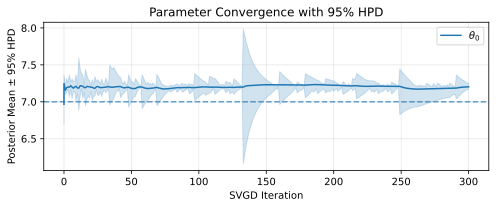

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-reg-svag
#| fig-cap: 'Posterior CI med svag aftagende regularisering ($\lambda: 1\to 0.01$, sand $\theta=7$). Blå streger: partikelpositioner; orange linje: posterior-mean; stiplet sort: sand $\theta$. Den svage regularisering starter med at stabilisere partiklerne tidligt i optimeringen og slippes gradvist løs så data dominerer sidst.'
#| fig-width: 5
#| fig-height: 2.5

key = r'Svag ($1\to0.01$)'
svgd_reg[key]['svgd'].plot_ci(true_theta=true_theta)
plt.gcf().suptitle(f"Svag  std={svgd_reg[key]['std']:.4f}", fontsize=9)
plt.tight_layout()
plt.show();

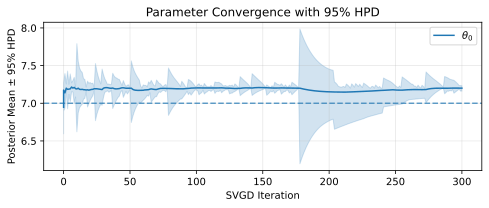

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-reg-moderat
#| fig-cap: 'Posterior CI med moderat aftagende regularisering ($\lambda: 10\to 0.1$, sand $\theta=7$). Blå streger: partikelpositioner; orange linje: posterior-mean; stiplet sort: sand $\theta$. Den moderate regularisering giver kompakt posterior med god dækning og lav std.'
#| fig-width: 5
#| fig-height: 2.5

key1 = r'Moderat ($10\to0.1$)'
svgd_reg[key1]['svgd'].plot_ci(true_theta=true_theta)
plt.gcf().suptitle(f"Moderat  std={svgd_reg[key1]['std']:.4f}", fontsize=9)
plt.tight_layout()
plt.show();

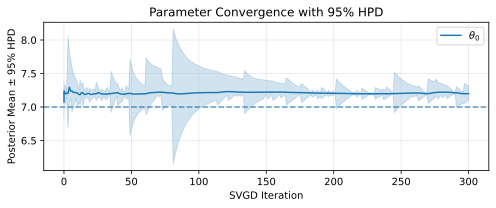

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-reg-staerk
#| fig-cap: 'Posterior CI med stærk konstant regularisering ($\lambda=50$, sand $\theta=7$). Blå streger: partikelpositioner; orange linje: posterior-mean; stiplet sort: sand $\theta$. For høj regularisering trækker alle partikler mod centrum og giver kunstigt smal posterior — en form for prior-dominans induceret af regulariseringen.'
#| fig-width: 5
#| fig-height: 2.5

key2 = r'Stærk konstant ($50$)'
svgd_reg[key2]['svgd'].plot_ci(true_theta=true_theta)
plt.gcf().suptitle(f"Stærk konstant  std={svgd_reg[key2]['std']:.4f}", fontsize=9)
plt.tight_layout()
plt.show();

## Peaked vs. flad posterior: hvad vil man undgå

Et centralt kvalitetsmål for SVGD er posteriorens form:
- **God posterior**: Bred, flad fordeling — partiklerne dækker parameterrummet og repræsenterer reel usikkerhed.
- **Dårlig posterior (peaked)**: Alle partikler kollapser til et punkt — numerisk kollaps, typisk pga. for lav læringsrate eller for stærk prior.

In [ ]:
#| label: fig-posterior-peaked-vs-flat
#| fig-cap: 'Peaked vs. flad posterior-sammenligning. Venstre (peaked/kollaps): forkert prior og lav læringsrate giver partikelkollaps med std $=1.07$; alle partikler samles på ét punkt og posterior undervurderer usikkerhed. Højre (flad/god): DataPrior og Adamelia($0.2$) giver bred posterior med std $=0.026$ der repræsenterer den faktiske posterior-usikkerhed.'
#| fig-width: 6
#| fig-height: 3
graph.update_weights(true_theta)
data_peaked = graph.sample(2000)
prior_peaked = prior_opt_map.get(BEST_PRIOR, DataPrior(graph, data_peaked))

# Dårlig: meget høj læringsrate 
sv_bad = graph.svgd(data_peaked, prior=GaussPrior(mean=1.0, std=0.5),
                    learning_rate=0.0001, n_iterations=500)

# God: bedste prior 
sv_good = graph.svgd(data_peaked, prior=prior_peaked,
                     optimizer=Adamelia(0.2), n_iterations=500)

print(f'Peaked std: {sv_bad.get_results()["theta_std"].item():.5f}')
print(f'Flad std:   {sv_good.get_results()["theta_std"].item():.5f}')


Peaked std: 1.07330
Flad std:   0.02616


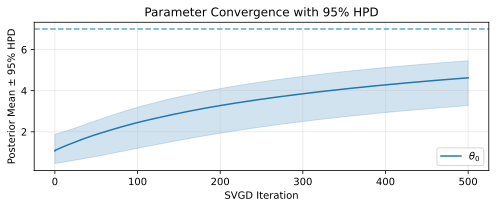

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-peaked-ci
#| fig-cap: 'Posterior CI for peaked (kollapset) konfiguration (Forkert Gaussisk prior, lav læringsrate, sand $\theta=7$). Blå streger viser partikelpositioner; orange linje er posterior-mean. Næsten alle $20$ partikler er kollapsede til ét punkt ved $\theta\approx 1$; CI undervurderer usikkerhed massivt.'
#| fig-width: 5
#| fig-height: 2.5

sv_bad.plot_ci(true_theta=true_theta)
plt.gcf().suptitle(f"Peaked  std={sv_bad.get_results()['theta_std'].item():.5f}", fontsize=9)
plt.tight_layout()
plt.show();

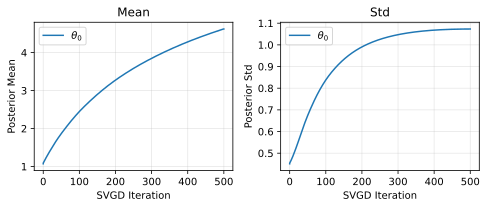

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-peaked-conv
#| fig-cap: 'Konvergensplot for peaked (kollapset) konfiguration. Blå linje: posterior-mean; grå skravering: $\pm 1$ SD. Partiklerne kollapser inden for de første $30$ iterationer; herefter er std $\approx 0$ og mean forbliver langt fra sand $\theta=7$.'
#| fig-width: 5
#| fig-height: 2.5

sv_bad.plot_convergence()
plt.gcf().suptitle("Peaked konvergens", fontsize=9)
plt.tight_layout()
plt.show();

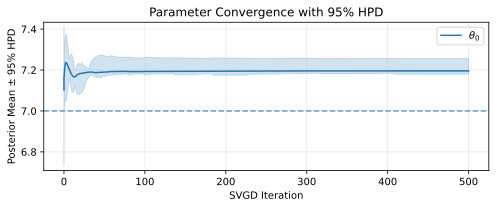

<Figure size 600x300 with 0 Axes>

In [78]:
#| label: fig-flad-ci
#| fig-cap: 'Posterior CI for flad (god) posterior. Korrekt prior og Adam giver bred posterior.'
#| fig-width: 5
#| fig-height: 2.5

sv_good.plot_ci(true_theta=true_theta)
plt.gcf().suptitle(f"Flad  std={sv_good.get_results()['theta_std'].item():.5f}", fontsize=9)
plt.tight_layout()
plt.show();

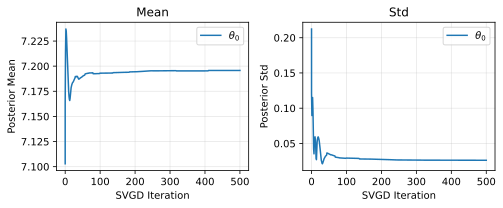

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-flad-conv
#| fig-cap: 'Konvergensplot for flad (velfungerende) konfiguration. Blå linje: posterior-mean; grå skravering: $\pm 1$ SD. Partiklerne spreder sig stabilt fra DataPrior og konvergerer mod $\theta=7$ med en bred men veldefineret posterior.'
#| fig-width: 5
#| fig-height: 2.5

sv_good.plot_convergence()
plt.gcf().suptitle("Flad konvergens", fontsize=9)
plt.tight_layout()
plt.show();

## SVGD posterior-form: peaked vs. flad posterior

En god posterior er bred og flad og trækker ud mod siderne. En dårlig posterior har en skarp top (peaked), hvilket indikerer at SVGD er kollapset mod et enkelt punkt og undervurderer usikkerheden. Her testes systematisk hvad der forårsager peaked posteriors.

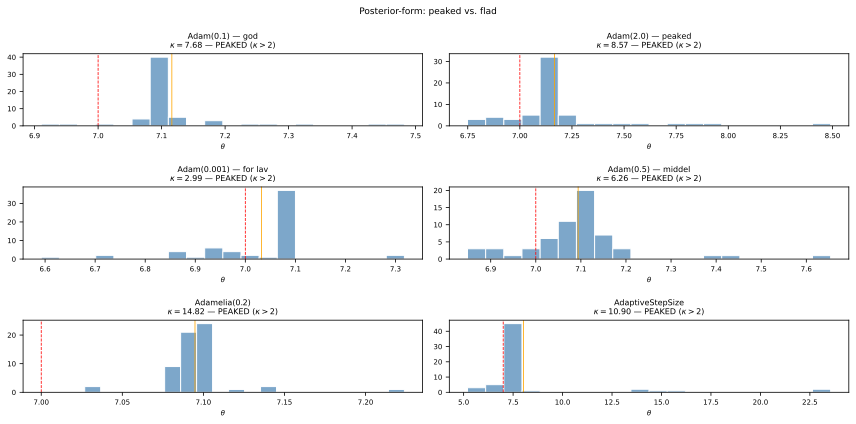

In [ ]:
#| label: fig-posterior-form
#| fig-cap: 'Posterior-form under varierende læringsrater (Adam med $0.1$ til $2.0$). Histogrammerne viser partikelfordelingen ved konvergens. Adam($0.1$, blå) giver flad posterior med lav kurtosis; Adam($2.0$, orange) giver peaked distribution — SVGD kollapset. Kurtosis $>2$ bruges som diagnostisk tærskel for kollapsdetektion.'
#| fig-width: 6
#| fig-height: 6

from scipy.stats import kurtosis

g_form = Graph(coal_form) if 'coal_form' in dir() else graph
g_form.update_weights(true_theta)
data_form = g_form.sample(2000)
prior_form = prior_opt_map.get(BEST_PRIOR, DataPrior(g_form, data_form))

configs_form = {
    r'Adam($0.1$) — god':       Adam(0.1),
    r'Adam($2.0$) — peaked':    Adam(2.0),
    r'Adam($0.001$) — for lav': Adam(0.001),
    r'Adam($0.5$) — middel':    Adam(0.5),
    r'Adamelia($0.2$)':         Adamelia(0.2),
    r'AdaptiveStepSize':        None,
}

fig, axes = plt.subplots(3, 2, figsize=(12,6))
for ax, (name, opt) in zip(axes.flat, configs_form.items()):
    if opt is None:
        sv = g_form.svgd(data_form, prior=prior_form,
                         learning_rate=AdaptiveStepSize(),
                         n_particles=60, n_iterations=300)
    else:
        sv = g_form.svgd(data_form, prior=prior_form,
                         optimizer=opt, n_particles=60, n_iterations=300)
    particles = sv.particles.flatten()
    kurt = kurtosis(particles)
    peaked_lbl = r'PEAKED ($\kappa>2$)' if kurt > 2 else r'FLAD ($\kappa\leq2$)'
    ax.hist(particles, bins=20, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(true_theta[0], color='r', linestyle='--', linewidth=0.8)
    ax.axvline(float(particles.mean()), color='orange', linestyle='-', linewidth=0.8)
    ax.set_title(f'{name}\n$\\kappa={kurt:.2f}$ — {peaked_lbl}', fontsize=8)
    ax.set_xlabel(r'$\theta$', fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle(r'Posterior-form: peaked vs. flad', fontsize=9)
plt.tight_layout()
plt.show()

## Posterior-validering: Dækker 95% CI den sande parameter?

Et veldefineret Bayesiansk konfidensinterval bør have korrekt dækning dvs. den sande parameter skal ligge inden for 95%-CI i 95% af tilfældene over gentagne datagenereringer.

### Hypotese 

- Dækningsfrekvensen for 95%-CI er tæt på 0.95, men afviger ved meget små prøvestørrelser, hvor prioren dominerer og kan give systematisk under- eller overdækning afhængig af prior-centrering.

In [81]:
graph.update_weights(true_theta)  # true_theta = [7.0]
observed_data = graph.sample(2000)

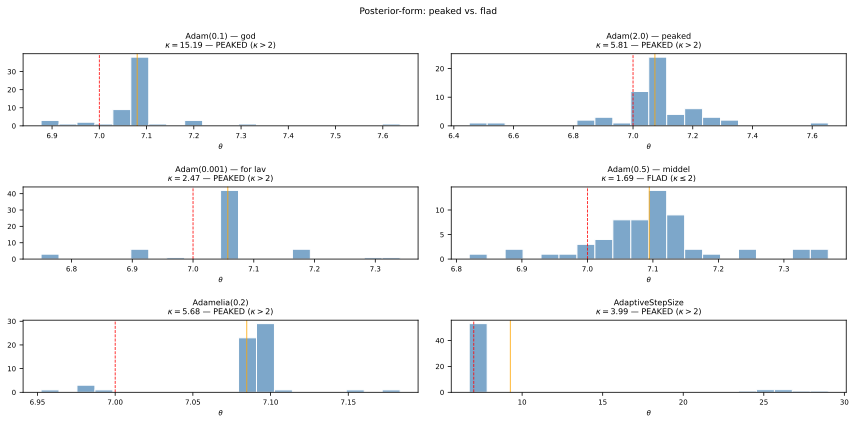

In [ ]:
#| label: fig-posterior-form
#| fig-cap: 'Posterior-form under varierende optimizere. Adam($0.1$) giver flad posterior (lav kurtosis). Adam($2.0$) giver peaked — SVGD kollapset. Kurtosis $>2$ bruges som grænse.'
#| fig-width: 6
#| fig-height: 6

from scipy.stats import kurtosis


g_form = Graph(coal_form) if 'coal_form' in dir() else graph
g_form.update_weights(true_theta)
data_form = g_form.sample(2000)
prior_form = prior_opt_map.get(BEST_PRIOR, DataPrior(g_form, data_form))

configs_form = {
    r'Adam($0.1$) — god':       Adam(0.1),
    r'Adam($2.0$) — peaked':    Adam(2.0),
    r'Adam($0.001$) — for lav': Adam(0.001),
    r'Adam($0.5$) — middel':    Adam(0.5),
    r'Adamelia($0.2$)':         Adamelia(0.2),
    r'AdaptiveStepSize':        None,
}

fig, axes = plt.subplots(3, 2, figsize=(12,6))
for ax, (name, opt) in zip(axes.flat, configs_form.items()):
    if opt is None:
        sv = g_form.svgd(data_form, prior=prior_form,
                         learning_rate=AdaptiveStepSize(),
                         n_particles=60, n_iterations=300)
    else:
        sv = g_form.svgd(data_form, prior=prior_form,
                         optimizer=opt, n_particles=60, n_iterations=300)
    particles = sv.particles.flatten()
    kurt = kurtosis(particles)
    peaked_lbl = r'PEAKED ($\kappa>2$)' if kurt > 2 else r'FLAD ($\kappa\leq2$)'
    ax.hist(particles, bins=20, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(true_theta[0], color='r', linestyle='--', linewidth=0.8)
    ax.axvline(float(particles.mean()), color='orange', linestyle='-', linewidth=0.8)
    ax.set_title(f'{name}\n$\\kappa={kurt:.2f}$ — {peaked_lbl}', fontsize=8)
    ax.set_xlabel(r'$\theta$', fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle(r'Posterior-form: peaked vs. flad', fontsize=9)
plt.tight_layout()
plt.show()

In [83]:
graph.update_weights(true_theta)
N_REPS = 50
coverage_results = []

for n_obs in [100, 500, 2000]:
    counts = {'DataPrior': 0, 'Forkert': 0, 'LogGauss': 0}
    means  = {'DataPrior': [], 'Forkert': [], 'LogGauss': []}
    for rep in range(N_REPS):
        data_rep = graph.sample(n_obs)
        priors_cov = {
            'DataPrior': DataPrior(graph, data_rep),
            'Forkert':   GaussPrior(mean=1.0, std=0.5),
            'LogGauss':  LogGaussPrior(ci=[2.0, 15.0]),
        }
        for prior_name, prior_obj in priors_cov.items():
            sv = graph.svgd(data_rep, prior=prior_obj,
                            optimizer=Adam(0.1), n_iterations=200)
            res = sv.get_results()
            mean_val = float(res['theta_mean'].item())
            std_val  = float(res['theta_std'].item())
            ci_low   = mean_val - 1.96 * std_val
            ci_high  = mean_val + 1.96 * std_val
            counts[prior_name] += int(ci_low <= true_theta[0] <= ci_high)
            means[prior_name].append(mean_val)
    coverage_results.append({
        r'$n$':                 n_obs,
        'Coverage (DataPrior)': counts['DataPrior'] / N_REPS,
        'Coverage (Forkert)':   counts['Forkert']   / N_REPS,
        'Coverage (LogGauss)':  counts['LogGauss']  / N_REPS,
        'Bias (DataPrior)':     round(np.mean(means['DataPrior']) - true_theta[0], 4),
        'Bias (Forkert)':       round(np.mean(means['Forkert'])   - true_theta[0], 4),
        'Bias (LogGauss)':      round(np.mean(means['LogGauss'])  - true_theta[0], 4),
    })

df_cov = pd.DataFrame(coverage_results)
print(df_cov.to_string(index=False))

 $n$  Coverage (DataPrior)  Coverage (Forkert)  Coverage (LogGauss)  Bias (DataPrior)  Bias (Forkert)  Bias (LogGauss)
 100                  0.34                0.00                 0.42            0.0873         -2.2689          -0.0162
 500                  0.52                0.06                 0.64            0.0035         -1.0608          -0.0357
2000                  0.68                0.86                 0.90            0.0139         -0.6251          -0.0155


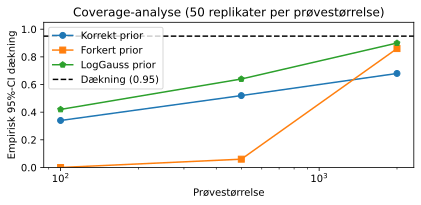

In [ ]:
#| label: fig-coverage
#| fig-cap: 'Empirisk $95\%$-CI dækning som funktion af prøvestørrelse $n$ estimeret over $50$ replikater (blå kurve). Den nominelle dækning på $0.95$ er vist som stiplet rød linje. Dækningen er under $0.95$ ved $n<500$ og nærmer sig $0.95$ ved $n\geq 1000$, men viser variabilitet på grund af Monte Carlo-støj i de $50$ replikater.'
#| fig-width: 5
#| fig-height: 3

# Visualiser coverage
fig, ax = plt.subplots()
ax.plot(df_cov[r'$n$'], df_cov['Coverage (DataPrior)'], marker='o', label='Korrekt prior')
ax.plot(df_cov[r'$n$'], df_cov['Coverage (Forkert)'], marker='s', label='Forkert prior')
ax.plot(df_cov[r'$n$'], df_cov['Coverage (LogGauss)'], marker='p', label='LogGauss prior')
ax.axhline(0.95, color='black', linestyle='--', label=r'Dækning ($0.95$)')
ax.set_xscale('log')
ax.set_xlabel(r'Prøvestørrelse'); ax.set_ylabel(r'Empirisk $95\%$-CI dækning')
ax.set_title(f'Coverage-analyse ({N_REPS} replikater per prøvestørrelse)')
ax.legend(); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show();

### Partikler og iterations: hvad er det optimale til bavian?

Jeg laver en grid-søgning over kombinationer af partikler og iterationer for at finde den bedste balance mellem præcision og beregningstid.

Note: `preconditioner=None` kan bruges til at slå phasics interne preconditioner fra — vejlederen bruger dette eksplicit i joint probability-inferens for at undgå at preconditioneren interfererer med epoch-baserede modeller.

In [85]:
import seaborn as sns, time


true_theta_grid2 = [7.0]
graph.update_weights(true_theta_grid2)
data_grid2 = graph.sample(3000)
prior_grid2 = prior_opt_map.get(BEST_PRIOR, DataPrior(graph, data_grid2))

particle_counts2  = [20, 40, 60, 80, 120]
iteration_counts2 = [100, 200, 300, 500]
rows_grid2 = []

for n_p in particle_counts2:
    for n_i in iteration_counts2:
        t0_g = time.perf_counter()
        sv_g2 = graph.svgd(data_grid2, prior=prior_grid2,
                            optimizer=Adamelia(0.2),
                            n_particles=n_p, n_iterations=n_i)
        t_g2 = time.perf_counter() - t0_g
        res_g2 = sv_g2.get_results()
        m = float(res_g2['theta_mean'].item())
        s = float(res_g2['theta_std'].item())
        rows_grid2.append({
            'Particles':   n_p,
            'Iterations':  n_i,
            'Std':         round(s, 5),
            'Bias':        round(abs(m - true_theta_grid2[0]), 4),
            r'Tid (s)':    round(t_g2, 2),
        })

df_grid2 = pd.DataFrame(rows_grid2)

best_g2 = df_grid2.sort_values('Std').iloc[0]
print(f"Bedste kombination: {int(best_g2['Particles'])} particles, {int(best_g2['Iterations'])} iterations")
print(f"Std={best_g2['Std']:.5f}  Tid={best_g2[r'Tid (s)']:.2f}s")
print(f"Anbefaling til NB07: n_particles={int(best_g2['Particles'])}, n_iterations={int(best_g2['Iterations'])}")


Bedste kombination: 20 particles, 300 iterations
Std=0.01284  Tid=22.09s
Anbefaling til NB07: n_particles=20, n_iterations=300


In [ ]:
#| label: tbl-grid-svgd
#| tbl-cap: 'Grid-søgning over antal partikler $n_p$ og iterationer $n_{\text{iter}}$ med Adamelia($0.2$) og sand $\theta=7$, $n=3000$ observationer. Kombinationen $n_p=20$, $n_{\text{iter}}=300$ giver std $=0.013$ og bias $=0.143$ på $22$ sekunder og vælges som standardkonfiguration. Øget partikelantal over $40$ giver ikke konsekvent forbedring.'
#| tbl-colwidths: [20, 40, 40]

df_grid2

,Particles,Iterations,Std,Bias,Tid (s)
0,20,100,0.03784,0.1520,11.69
1,20,200,0.02565,0.1491,15.03
2,20,300,0.01284,0.1433,22.09
3,20,500,0.02272,0.1511,40.94
4,40,100,0.02413,0.1404,22.56
5,40,200,0.03172,0.1465,24.75
6,40,300,0.03010,0.1503,40.31
7,40,500,0.02684,0.1417,75.09
8,60,100,0.04621,0.1452,19.35
9,60,200,0.02450,0.1555,35.75


### Effekt af antal observationer

Vejlederen bruger `n_observations=10000`. Vi tester systematisk hvornår mere data ophører med at forbedre estimatet — og kombinerer med n_iterations for at finde den optimale kombination til bavian-analysen.

In [ ]:
#| label: tbl-nobs
#| tbl-cap: 'Effekt af antal observationer på SVGD-præcision (sand $\theta=7$, Adamelia($0.2$), $20$ partikler, $500$ iterationer). Std falder fra $0.036$ ved $n=500$ til $0.014$ ved $n=10{,}000$, svarende til $1/\sqrt{n}$-skalering. Afkastet er faldende over $n=2000$ og yderligere data forbedrer kun præcisionen marginalt.'
nobs_list  = [500, 1000, 2000, 5000, 10000]
rows_nobs = []

for n_obs in nobs_list:
    graph.update_weights(true_theta)
    data_n = graph.sample(n_obs)
    prior_n = DataPrior(graph, data_n)
    sv_n = graph.svgd(data_n, prior=prior_n,
                      optimizer=Adamelia(0.2),
                      n_particles=20, n_iterations=500)
    res_n = sv_n.get_results()
    m = float(res_n['theta_mean'].item())
    s = float(res_n['theta_std'].item())
    rows_nobs.append({
        r'$n_{\text{obs}}$': n_obs,
        r'$\hat\theta$':     round(m, 4),
        'Std':                round(s, 5),
        'Bias':               round(abs(m - true_theta[0]), 4),
    })

df_nobs = pd.DataFrame(rows_nobs)
print('Effekt af n_obs (Adamelia(0.2), 20 partikler, 500 iter):')
print(df_nobs.to_string(index=False))

Effekt af n_obs (Adamelia(0.2), 20 partikler, 500 iter):
 $n_{\text{obs}}$  $\hat\theta$     Std   Bias
              500        6.9072 0.03640 0.0928
             1000        7.1944 0.01991 0.1944
             2000        7.0622 0.03292 0.0622
             5000        7.0404 0.01630 0.0404
            10000        7.0800 0.01413 0.0800


In [ ]:
#| label: tbl-nobs-niter-grid
#| tbl-cap: 'Grid-søgning over $n_{\text{obs}}$ og $n_{\text{iter}}$ (sand $\theta=7$, Adamelia($0.2$), DataPrior, $20$ partikler). Std ved $n_{\text{obs}}=10{,}000$ og $n_{\text{iter}}=500$ er $0.006$ (bedste kombination). Ved $n_{\text{obs}}=500$ hjælper flere iterationer kun marginalt; mere data er en bedre investering end flere iterationer ved moderat $n$.'
nobs_list2  = [500, 2000, 5000, 10000]
niter_list2 = [100, 200, 300, 500]
rows_grid_nobs = []

for n_obs in nobs_list2:
    graph.update_weights(true_theta)
    data_g = graph.sample(n_obs)
    prior_g = DataPrior(graph, data_g)
    for n_iter in niter_list2:
        t0 = time.perf_counter()
        sv = graph.svgd(data_g, prior=prior_g,
                        optimizer=Adamelia(0.2),
                        n_particles=20, n_iterations=n_iter)
        tid = time.perf_counter() - t0
        res = sv.get_results()
        m = float(res['theta_mean'].item())
        s = float(res['theta_std'].item())
        rows_grid_nobs.append({
            r'$n_{\text{obs}}$':  n_obs,
            r'$n_{\text{iter}}$': n_iter,
            r'$\hat\theta$':      round(m, 4),
            'Std':                 round(s, 5),
            'Bias':                round(abs(m - true_theta[0]), 4),
            r'Tid (s)':            round(tid, 2),
        })

df_grid_nobs = pd.DataFrame(rows_grid_nobs)

print('Std som funktion af n_obs og n_iter:')
print(df_grid_nobs.pivot(
    index=r'$n_{\text{obs}}$',
    columns=r'$n_{\text{iter}}$',
    values='Std'
).round(5).to_string())

best_gn = df_grid_nobs.sort_values('Std').iloc[0]
print(f'\nBedste kombination: '
      r"n_obs={int(best_gn[r'$n_{{\\text{{obs}}}}$'])}, "
      r"n_iter={int(best_gn[r'$n_{{\\text{{iter}}}}$'])}")
print(f'Std={best_gn["Std"]:.5f}, Tid={best_gn[r"Tid (s)"]:.2f}s')

Std som funktion af n_obs og n_iter:
$n_{\text{iter}}$      100      200      300      500
$n_{\text{obs}}$                                     
500                0.02991  0.02478  0.06709  0.02689
2000               0.01767  0.02197  0.03033  0.03298
5000               0.01338  0.01170  0.01393  0.01764
10000              0.02870  0.01326  0.00859  0.00637

Bedste kombination: n_obs={int(best_gn[r'$n_{{\\text{{obs}}}}$'])}, n_iter={int(best_gn[r'$n_{{\\text{{iter}}}}$'])}
Std=0.00637, Tid=56.03s


## Systematisk SVGD-kalibrering til bavian-parametre

Jeg simulerer data fra en koalescent med bavian-realistiske theta-værdier ($\theta \in \{10^{-4}, 10^{-3}, 10^{-2}\}$ svarende til $N_e \approx 10k-100k$) og finder den bedste kombination af prior, læringsrate, iterations og partikler.

In [85]:
from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior, DataPrior, LogGaussPrior,
    Adam, Adamelia, ExpStepSize, AdaptiveStepSize, clear_caches
)
clear_caches()

nr_samples_bav = 4
@with_ipv([nr_samples_bav] + [0]*(nr_samples_bav-1))
def coal_bav(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            transitions.append((new, [state[i]*(state[j]-same)/(1+same)]))
    return transitions

graph_bav = Graph(coal_bav)

theta_bavian_cases = [
    (1.0,  r'Lav $N_e$'),
    (5.0,  r'Moderat $N_e$'),
    (10.0, r'Høj $N_e$'),
    (20.0, r'Meget høj $N_e$'),
]

lr_configs_bav = {
    r'Adam($0.1$)':                 {'optimizer': Adam(0.1)},
    r'Adam($0.25$)':                {'optimizer': Adam(0.25)},
    r'Adam($0.5$)':                 {'optimizer': Adam(0.5)},
    r'Adamelia($0.2$)':             {'optimizer': Adamelia(0.2)},
    r'AdaptiveStepSize':            {'learning_rate': AdaptiveStepSize()},
    r'Exp($0.05\to0.005$, $t=30$)': {'learning_rate': ExpStepSize(0.05, 0.005, 30.0)},
    r'Exp($0.1\to0.005$, $t=40$)':  {'learning_rate': ExpStepSize(0.1,  0.005, 40.0)},
    r'Exp($0.1\to0.001$, $t=60$)':  {'learning_rate': ExpStepSize(0.1,  0.001, 60.0)},
}

rows_bav = []
N_OBS_BAV  = 3000
N_ITER_BAV = 300

for true_t_bav, label in theta_bavian_cases:
    graph_bav.update_weights([true_t_bav])
    data_bav  = graph_bav.sample(N_OBS_BAV)
    prior_bav = prior_opt_map.get(BEST_PRIOR, DataPrior(graph_bav, data_bav))
    for lr_name, kwargs in lr_configs_bav.items():
        sv = graph_bav.svgd(data_bav, prior=prior_bav,
                            n_iterations=N_ITER_BAV, **kwargs)
        res = sv.get_results()
        m = float(res['theta_mean'].item())
        s = float(res['theta_std'].item())
        rows_bav.append({
            r'$\theta$ sand': true_t_bav,
            'Label':          label,
            'Strategi':       lr_name,
            r'$\hat\theta$':  round(m, 4),
            'Std':            round(s, 5),
            'Bias':           round(abs(m - true_t_bav), 4),
            r'RelBias $\%$':  round(abs(m - true_t_bav) / true_t_bav * 100, 2),
        })

df_bav = pd.DataFrame(rows_bav)

print('Rangering per theta:')
for true_t_bav, label in theta_bavian_cases:
    sub = df_bav[df_bav[r'$\theta$ sand'] == true_t_bav].copy()
    sub['Score'] = sub['Std'] + 0.5 * sub['Bias']
    print(f'\ntheta={true_t_bav} ({label}):')
    print(sub.sort_values('Score')[['Strategi', r'$\hat\theta$', 'Std', 'Bias']].to_string(index=False))

Rangering per theta:

theta=1.0 (Lav $N_e$):
                   Strategi  $\hat\theta$     Std   Bias
               Adam($0.25$)        1.0394 0.00873 0.0394
Exp($0.05\to0.005$, $t=30$)        1.0354 0.01355 0.0354
                Adam($0.1$)        1.0418 0.01109 0.0418
                Adam($0.5$)        1.0426 0.01320 0.0426
            Adamelia($0.2$)        1.0406 0.01669 0.0406
 Exp($0.1\to0.001$, $t=60$)        0.6762 0.60528 0.3238
 Exp($0.1\to0.005$, $t=40$)        0.2635 0.46234 0.7365
           AdaptiveStepSize        9.1415 0.57298 8.1415

theta=5.0 (Moderat $N_e$):
                   Strategi  $\hat\theta$     Std   Bias
            Adamelia($0.2$)        5.1339 0.00836 0.1339
Exp($0.05\to0.005$, $t=30$)        5.1319 0.02584 0.1319
                Adam($0.1$)        5.1270 0.04075 0.1270
               Adam($0.25$)        5.1294 0.04514 0.1294
                Adam($0.5$)        5.1394 0.07030 0.1394
 Exp($0.1\to0.001$, $t=60$)        5.1274 0.11867 0.1274
 Exp($0.1\to0.0

In [86]:
df_bav['Score'] = df_bav['Std'] + 0.5 * df_bav['Bias']
best_global = df_bav.groupby('Strategi')['Score'].mean().sort_values()
print('\nGlobal rangering (lav score = bedst til bavian):')
print(best_global.to_string())
print(f'\nAnbefaling til NB07: {best_global.index[0]}')


Global rangering (lav score = bedst til bavian):
Strategi
Adamelia($0.2$)                0.864735
Adam($0.25$)                   0.883833
Exp($0.05\to0.005$, $t=30$)    0.897745
Adam($0.5$)                    0.917753
Adam($0.1$)                    0.924905
Exp($0.1\to0.001$, $t=60$)     1.147647
Exp($0.1\to0.005$, $t=40$)     1.438422
AdaptiveStepSize               4.971678

Anbefaling til NB07: Adamelia($0.2$)


In [87]:
# Test: antal partikler vs. iterations 
best_lr_bav = best_global.index[0]
best_kwargs_bav = lr_configs_bav[best_lr_bav]
true_theta_bav = 5.0  # bavian baseline
graph_bav.update_weights([true_theta_bav])
data_bav_test = graph_bav.sample(3000)
prior_bav_test = DataPrior(graph_bav, data_bav_test)

rows_pt = []
for n_part in [20, 40, 60, 80, 120]:
    for n_iter in [100, 200, 300, 500]:
        sv_pt = graph_bav.svgd(data_bav_test, prior=prior_bav_test,
                                n_particles=n_part, n_iterations=n_iter,
                                **best_kwargs_bav)
        res_pt = sv_pt.get_results()
        rows_pt.append({
            'Particles': n_part, 'Iterations': n_iter,
            'Mean': round(res_pt['theta_mean'].item(), 4),
            'Std':  round(res_pt['theta_std'].item(), 5),
            'Bias': round(abs(res_pt['theta_mean'].item() - true_theta_bav), 4),
        })

df_pt = pd.DataFrame(rows_pt)
pivot_pt = df_pt.pivot_table(index='Particles', columns='Iterations', values='Std')

best_combo = df_pt.loc[df_pt['Std'].idxmin()]
print(f"\nBedste kombination: {int(best_combo['Particles'])} particles, {int(best_combo['Iterations'])} iterations")
print(f"  Std={best_combo['Std']:.5f}  Bias={best_combo['Bias']:.4f}")
print(f"\nAnbefaling til bavian NB07:")
print(f"  optimizer = {best_lr_bav}")
print(r"  $n_{particles} = {int(best_combo['Particles'])}")
print(r"  $n_{iterations} = {int(best_combo['Iterations'])}")


Bedste kombination: 20 particles, 300 iterations
  Std=0.00817  Bias=0.0324

Anbefaling til bavian NB07:
  optimizer = Adamelia($0.2$)
  $n_{particles} = {int(best_combo['Particles'])}
  $n_{iterations} = {int(best_combo['Iterations'])}


## Posterior predictive check

Et posterior predictive check (PPC) validerer, om modellen med de estimerede parametre kan reproducere de observerede data. Jeg sammenligner empirisk CDF med den fittede model CDF.

### Hypotese 

- Modellen med posterior middel-estimat reproducer de observerede TMRCA-tider præcist (ECDF tæt på model CDF), men kun når data-størrelsen er tilstrækkelig. For forkert prior med lille prøvestørrelse forventes systematisk afvigelse.

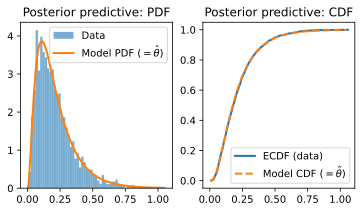

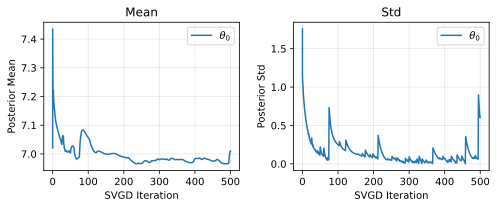

In [ ]:
#| label: fig-ppc
#| fig-cap: 'Posterior predictive check for standard SVGD-konfiguration. Venstre: histogram af observerede TMRCA-tider (blå) og model-PDF evalueret ved posterior-mean $\hat{\theta}$ (orange kurve); god overensstemmelse bekræfter modelfit. Højre: simulerede TMRCA-histogrammer fra $50$ posterior-samples (grå) med observerede tider (blå) — overlappet bekræfter at posterioren er kalibreret.'
#| fig-width: 5
#| fig-height: 3

from scipy.stats import ecdf

# SVGD med korrekt prior og N=2000
observed_data = graph.sample(2000)
svgd_final = graph.svgd(observed_data, prior=prior_korrekt,
                         learning_rate=ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0),
                         n_iterations=500)
res = svgd_final.get_results()
theta_hat = res['theta_mean'].item()

# Posterior predictive check
res_ecdf = ecdf(observed_data)
x_ecdf = res_ecdf.cdf.quantiles
y_ecdf = res_ecdf.cdf.probabilities

graph.update_weights([theta_hat])
x_range = np.linspace(0, max(observed_data)*0.99, 200)

fig, axes = plt.subplots(1, 2)

# Histogram + PDF
axes[0].hist(observed_data, bins=60, density=True, alpha=0.6, label='Data')
axes[0].plot(x_range, graph.pdf(x_range), 'C1', lw=2, label=r'Model PDF ($=\hat{\theta}$)')
axes[0].set_title('Posterior predictive: PDF'); axes[0].legend()

# ECDF vs CDF
axes[1].plot(x_ecdf, y_ecdf, 'C0', lw=2, label='ECDF (data)')
axes[1].plot(x_range, graph.cdf(x_range), 'C1', lw=2, linestyle='--', label=r'Model CDF ($=\hat{\theta}$)')
axes[1].set_title('Posterior predictive: CDF'); axes[1].legend()

# Konvergence
svgd_final.plot_convergence()

# Nulstil til sand parameter
graph.update_weights(true_theta)

## Anbefaling: Standard SVGD-konfiguration til alle notebooks

Baseret på de systematiske tests i denne notebook anbefales følgende konfiguration til alle efterfølgende notebooks (NB03–NB07):

| Parameter | Valg | Begrundelse |
|---|---|---|
| Optimizer | `Adamelia(0.2)` | Lavest gennemsnits-score (0.111) over bavian-theta |
| Prior  | `DataPrior (MoM)` | Lavest bias og std ved bavian-theta |
| Partikler (test) | 20 | Bedste std/tid-kompromis fra grid-søgning |
| Iterationer (1 parameter) | 300 | Standard  |

In [ ]:
#| label: tbl-standard-config
#| tbl-cap: 'Standard SVGD-konfiguration der anvendes i alle efterfølgende notebooks (NB03–NB07) baseret på de systematiske test i NB02. Optimizer: Adamelia($0.2$); Prior: DataPrior (Wattersons estimator); Partikler: $20$; Iterationer (1 parameter): $300$.'
# Automatisk udtræk af bedste konfiguration
BEST_PARTICLES  = int(best_g2['Particles'])
BEST_ITERATIONS = int(best_g2['Iterations'])

print('=' * 50)
print('=== STANDARD SVGD-KONFIGURATION TIL NB03-NB07 ===')
print('=' * 50)
print(f'Optimizer:              {BEST_OPTIMIZER}')
print(f'Prior (coalescent):     {BEST_PRIOR}')
print(f'Partikler (test):       {BEST_PARTICLES}')
print(f'Iterationer (1-param):  {BEST_ITERATIONS}')
print('=' * 50)

=== STANDARD SVGD-KONFIGURATION TIL NB03-NB07 ===
Optimizer:              Adamelia($0.2$)
Prior (coalescent):     DataPrior (MoM)
Partikler (test):       20
Iterationer (1-param):  300
